# NeuroBEM — noise & data-quality EDA

Noise = raw − low-pass(raw), ranked by SNR (lower = noisier). Helpers in `utility.py`. Each section is shown for the **wild** flight, then the **calm** flight.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utility as u

WILD = '2021-02-23-22-54-17'   # ellipse, ~19 m/s (aggressive)
CALM = '2021-02-23-10-43-02'   # slow lemniscate, vel=0.35 (calm)
wild = u.load_largest_segment(WILD)
calm = u.load_largest_segment(CALM)
print('wild', wild.shape, '| calm', calm.shape)

wild (16909, 29) | calm (11743, 29)


## Inspect all columns

In [20]:
wild.describe().T

,count,mean,std,min,25%,50%,75%,max
t,16909.0,22.747500,12.203380,1.612500,12.180000,22.747500,33.315000,43.882500
ang_acc_x,16909.0,-0.001483,4.101442,-25.581201,-1.933813,0.053337,1.845971,37.484898
ang_acc_y,16909.0,-0.000352,3.880329,-16.622462,-1.789928,-0.070773,1.654263,35.627037
ang_acc_z,16909.0,-0.000812,1.392037,-7.155445,-0.739582,0.003627,0.747685,8.204720
ang_vel_x,16909.0,-0.039873,1.359791,-3.254800,-0.768441,-0.000586,0.753509,3.182427
ang_vel_y,16909.0,0.003593,1.297118,-3.362866,-0.766616,0.002160,0.701565,3.347655
ang_vel_z,16909.0,-0.054792,0.098031,-0.610314,-0.107622,-0.025869,0.005428,0.187680
qx,16909.0,0.002434,0.336997,-0.613730,-0.214982,-0.004720,0.250530,0.612549
qy,16909.0,-0.001955,0.343676,-0.639768,-0.267151,0.002910,0.236129,0.639038
qz,16909.0,0.116805,0.576093,-0.817314,-0.373617,0.040782,0.675125,0.977978


In [21]:
calm.describe().T

,count,mean,std,min,25%,50%,75%,max
t,11743.0,30.195000,8.475141,15.517500,22.856250,30.195000,37.533750,44.872500
ang_acc_x,11743.0,0.000313,1.327358,-5.348721,-0.845127,0.013432,0.829744,5.645620
ang_acc_y,11743.0,0.002657,1.094982,-5.598199,-0.740047,-0.019359,0.735519,4.116258
ang_acc_z,11743.0,-0.000091,0.635849,-1.886399,-0.425371,0.004906,0.424640,2.031639
ang_vel_x,11743.0,-0.001812,0.063551,-0.186965,-0.035057,0.002839,0.031938,0.225432
ang_vel_y,11743.0,0.001405,0.035813,-0.110137,-0.019852,0.000659,0.020404,0.149016
ang_vel_z,11743.0,0.000550,0.011308,-0.031809,-0.006519,-0.000073,0.007144,0.053602
qx,11743.0,0.001649,0.042848,-0.079313,-0.023780,0.003905,0.027258,0.090157
qy,11743.0,-0.000808,0.027289,-0.045005,-0.016535,-0.006128,0.016140,0.070306
qz,11743.0,0.024155,0.004268,0.017184,0.020241,0.023259,0.028713,0.031648


## Integrity

In [22]:
pd.Series(u.integrity_report(wild))

n_samples     16909.00
duration_s       42.27
dt_std_ms         0.00
n_nan             0.00
n_gaps            0.00
dtype: float64

In [23]:
pd.Series(u.integrity_report(calm))

n_samples     11743.00
duration_s       29.36
dt_std_ms         0.00
n_nan             0.00
n_gaps            0.00
dtype: float64

## Raw vs smoothed (1 s window)

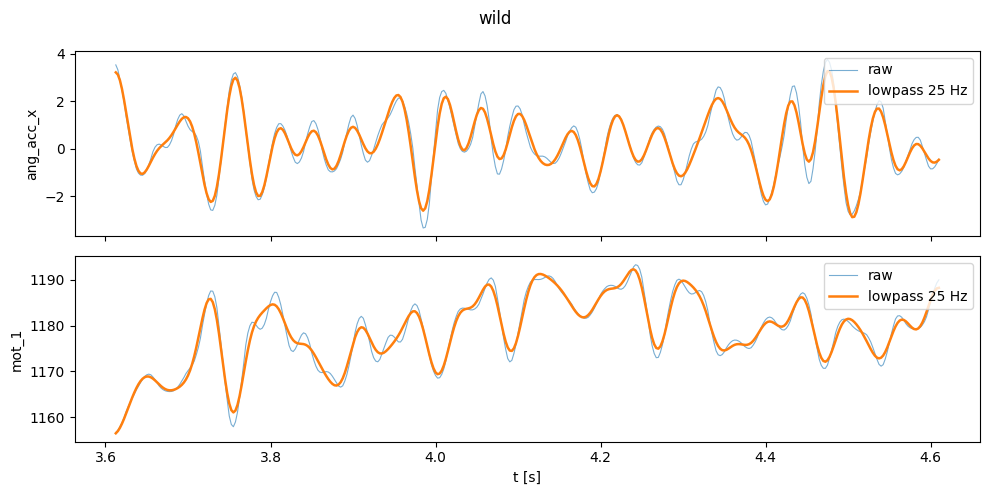

In [24]:
t = wild['t'].to_numpy(); win = (t >= t[0] + 2) & (t < t[0] + 3)
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for a, ch in zip(ax, ['ang_acc_x', 'mot_1']):
    x = wild[ch].to_numpy()
    a.plot(t[win], x[win], lw=0.8, alpha=0.6, label='raw')
    a.plot(t[win], u.lowpass(x)[win], lw=1.8, label='lowpass 25 Hz')
    a.set_ylabel(ch); a.legend(loc='upper right')
ax[-1].set_xlabel('t [s]'); fig.suptitle('wild'); plt.tight_layout()

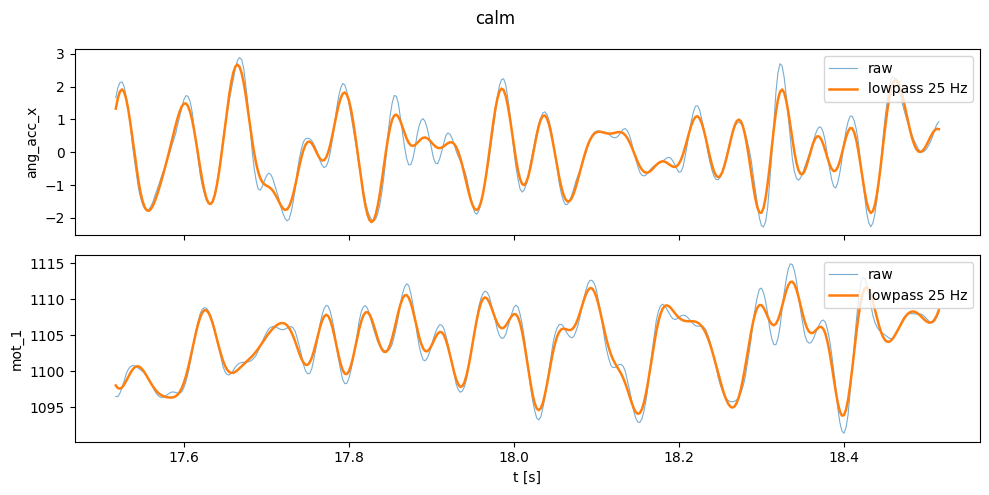

In [25]:
t = calm['t'].to_numpy(); win = (t >= t[0] + 2) & (t < t[0] + 3)
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for a, ch in zip(ax, ['ang_acc_x', 'mot_1']):
    x = calm[ch].to_numpy()
    a.plot(t[win], x[win], lw=0.8, alpha=0.6, label='raw')
    a.plot(t[win], u.lowpass(x)[win], lw=1.8, label='lowpass 25 Hz')
    a.set_ylabel(ch); a.legend(loc='upper right')
ax[-1].set_xlabel('t [s]'); fig.suptitle('calm'); plt.tight_layout()

## SNR ranking (lower = noisier)

Position & quaternion dropped (absolute pose, not a noise question).

In [26]:
drop = ['pos_x', 'pos_y', 'pos_z', 'qx', 'qy', 'qz', 'qw']
snr_wild = u.snr_table(wild.drop(columns=drop))
snr_wild

,snr_db
dmot_3,5.190301
dmot_1,5.461774
dmot_2,5.528221
dmot_4,5.751745
ang_acc_z,8.985174
ang_acc_x,15.213695
ang_acc_y,18.350473
ang_vel_z,24.372652
mot_3,40.338949
mot_1,41.218613


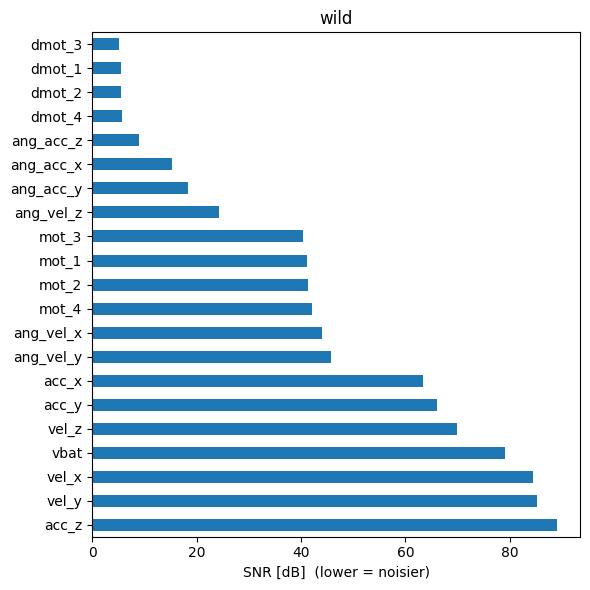

In [27]:
snr_wild['snr_db'].plot.barh(figsize=(6, 6)); plt.gca().invert_yaxis()
plt.xlabel('SNR [dB]  (lower = noisier)'); plt.title('wild'); plt.tight_layout()

In [28]:
snr_calm = u.snr_table(calm.drop(columns=drop))
snr_calm

,snr_db
dmot_4,6.780195
dmot_1,8.689175
dmot_3,8.950977
dmot_2,9.431164
ang_acc_z,11.243788
ang_vel_z,13.819350
ang_acc_x,15.266757
ang_acc_y,17.674260
ang_vel_y,25.517523
ang_vel_x,26.801356


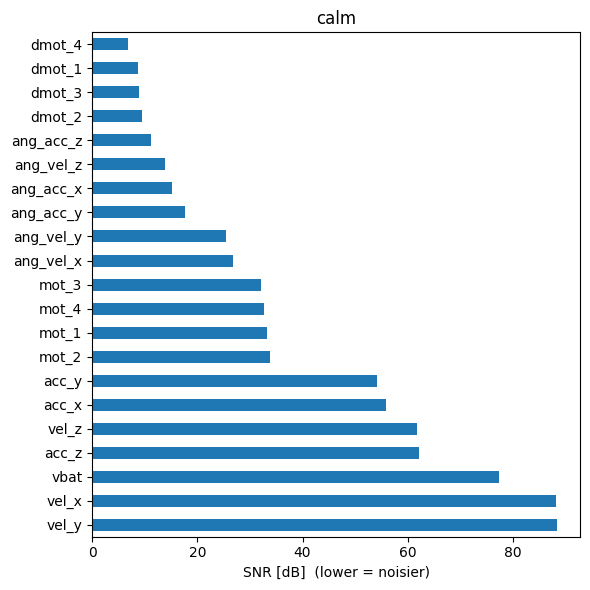

In [29]:
snr_calm['snr_db'].plot.barh(figsize=(6, 6)); plt.gca().invert_yaxis()
plt.xlabel('SNR [dB]  (lower = noisier)'); plt.title('calm'); plt.tight_layout()